In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Veri setinin kök yolu (projemize göre)
VERI_YOLU = "../data/UCI HAR Dataset"

# Hangi hareketler var? activity_labels.txt dosyasını okuyalım
etiketler = pd.read_csv(
    f"{VERI_YOLU}/activity_labels.txt",
    sep=r"\s+",          # sütunlar boşlukla ayrılmış
    header=None,
    names=["id", "hareket"]
)

print("Bu veri setindeki hareketler:")
print(etiketler)

Bu veri setindeki hareketler:
   id             hareket
0   1             WALKING
1   2    WALKING_UPSTAIRS
2   3  WALKING_DOWNSTAIRS
3   4             SITTING
4   5            STANDING
5   6              LAYING


In [2]:
# Ham ivmeölçer sinyallerini yükleyelim (x, y, z eksenleri)
# Her dosya: her satır = bir hareket örneği, her satırda 128 zaman adımı

def sinyal_yukle(dosya_adi):
    yol = f"{VERI_YOLU}/train/Inertial Signals/{dosya_adi}"
    return pd.read_csv(yol, sep=r"\s+", header=None).values

# Vücut ivmesinin üç ekseni
acc_x = sinyal_yukle("body_acc_x_train.txt")
acc_y = sinyal_yukle("body_acc_y_train.txt")
acc_z = sinyal_yukle("body_acc_z_train.txt")

# Etiketler: her örnek hangi harekete ait?
y = pd.read_csv(f"{VERI_YOLU}/train/y_train.txt", header=None).values.ravel()

print("acc_x boyutu:", acc_x.shape)
print("Toplam örnek sayısı:", acc_x.shape[0])
print("Her örnekteki zaman adımı:", acc_x.shape[1])
print("Etiket sayısı:", y.shape)
print("İlk 10 etiket:", y[:10])

acc_x boyutu: (7352, 128)
Toplam örnek sayısı: 7352
Her örnekteki zaman adımı: 128
Etiket sayısı: (7352,)
İlk 10 etiket: [5 5 5 5 5 5 5 5 5 5]


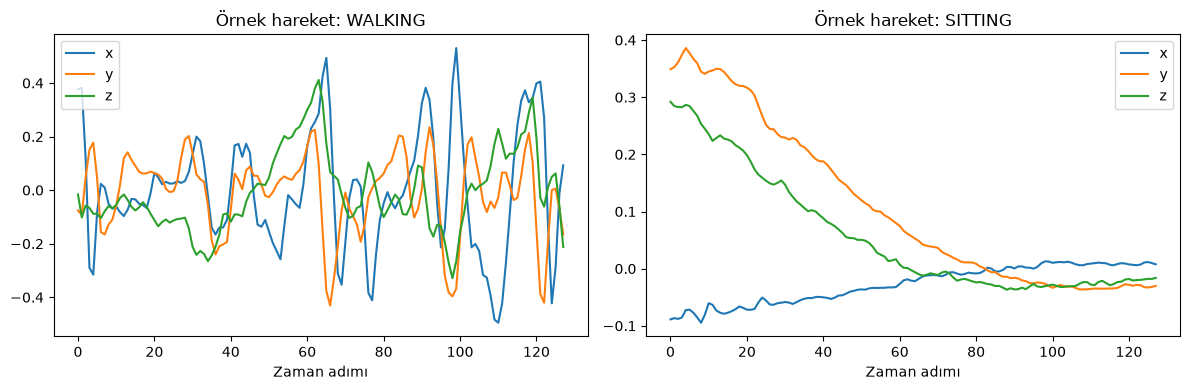

In [3]:
# activity_labels'ı bir sözlüğe çevirelim (numara -> isim)
isim = dict(zip(etiketler["id"], etiketler["hareket"]))

# Bir YÜRÜME örneği (etiket 1) ve bir OTURMA örneği (etiket 4) bulalım
yurume_index = np.where(y == 1)[0][0]   # ilk yürüme örneğinin sırası
oturma_index = np.where(y == 4)[0][0]   # ilk oturma örneğinin sırası

fig, eksenler = plt.subplots(1, 2, figsize=(12, 4))

# Sol grafik: yürüme
eksenler[0].plot(acc_x[yurume_index], label="x")
eksenler[0].plot(acc_y[yurume_index], label="y")
eksenler[0].plot(acc_z[yurume_index], label="z")
eksenler[0].set_title(f"Örnek hareket: {isim[1]}")
eksenler[0].set_xlabel("Zaman adımı")
eksenler[0].legend()

# Sağ grafik: oturma
eksenler[1].plot(acc_x[oturma_index], label="x")
eksenler[1].plot(acc_y[oturma_index], label="y")
eksenler[1].plot(acc_z[oturma_index], label="z")
eksenler[1].set_title(f"Örnek hareket: {isim[4]}")
eksenler[1].set_xlabel("Zaman adımı")
eksenler[1].legend()

plt.tight_layout()
plt.show()